In [1]:
!pip install "textdistance[extras]"
!pip install cerebras-cloud-sdk

!pip install "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git"

!pip install vllm==0.13.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 2.7 MB/s eta 0:00:00
  Cloning https://github.com/unslothai/unsloth.git to /tmp/pip-install-djsrknh7/unsloth_015cfcdd3e574bf596dbf9b5617ac832
  Running command git clone --filter=blob:none --quiet https://github.com/unslothai/unsloth.git /tmp/pip-install-djsrknh7/unsloth_015cfcdd3e574bf596dbf9b5617ac832
  Resolved https://github.com/unslothai/unsloth.git to commit ecd584a9167e1637b0a0e916af3c5b88690e24fb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 26.4 MB/s eta 0:00

In [2]:
import os
import sys

key_names = ["CEREBRAS_API_KEY", "DEEPSEEK_API_KEY"]
try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    for name in key_names:
        try:
            val = user_secrets.get_secret(name)
            os.environ[name] = val
        except Exception:
            print(f"⚠️ {name} not found in Kaggle secrets.")
    print("✅ API Keys loaded from Kaggle Secrets.")
    
except ImportError:
    # ---------------------------
    # Fallback / Local
    # ---------------------------
    print("❌ Not running in Colab or Kaggle (or libraries missing).")
    print("   Ensure keys are set manually in os.environ or a .env file.")

✅ API Keys loaded from Kaggle Secrets.


#### LLM as a judge for quality of the query

In [3]:
import os
import json
import re
from openai import OpenAI

# --- 1. CONFIGURATION ---

client = OpenAI(
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com"
)

JUDGE_MODEL_ID = "deepseek-chat"

# --- 2. PROMPT DEFINITIONS (Aligned with Cerebras Strategy) ---

# Updated to include the {examples} placeholder for Few-Shot prompting
BASE_SYSTEM_INSTRUCTIONS = """
You are a Senior SQL Expert and Data Product Manager.
Your task is to evaluate a Candidate SQL query generated from a French User Request against an English Database Schema.

Target Audience: The user is a non-technical business user.
Output Format: A single valid JSON object.

Evaluation Criteria:
1. LOGIC CORRECTNESS: Does the query return the accurate data requested? (Crucial: Watch for translation errors in WHERE clauses, wrong column usage, or invalid syntax).
2. SELECTION RELEVANCE: Does the query select meaningful columns? (e.g., 'product_name' vs 'id').
3. IMPLICIT COMPLETENESS: Does it include essential context not explicitly asked for? (e.g., date + amount).
4. ALIASING & NAMING: Are column aliases used for readability (it should be in French)? (e.g., 'AS revenue_total').

Warning:
The sql gold query is just a refrence for a good result. It might sometimes be wrong as it might be correct.

### FEW-SHOT EXAMPLES ###
{examples}
"""

# Synthetic examples (Same as Cerebras implementation)
examples = """
--- Example 1: Translation Mismatch (Value Error) ---
User Request: "Montre les événements de guerres civiles"
Gold SQL: SELECT * FROM events WHERE EventCode LIKE '%GUERRES CIVILES%'
Candidate SQL: SELECT * FROM events WHERE EventCode LIKE '%Civil War%'
Response: {
  "is_logically_correct": false,
  "selection_quality_score": 0.0,
  "completeness_score": 0.5,
  "aliasing_score": 0.0,
  "reasoning": "Major Logic Error. the EventCode field does not store text descriptions like "GUERRES CIVILES" (French for "Civil Wars"). Instead, it uses CAMEO (Conflict and Mediation Event Observations) codes, which are numeric strings (e.g., '190', '145').The only good part here is completness because it takes all columns but this is not optimal"
}

--- Example 2: Wrong Column (Semantics Error) ---
User Request: "Acteurs de religion Chiite"
Gold SQL: SELECT Name FROM actors WHERE Actor1Religion1Code = 'SHI'
Candidate SQL: SELECT Name FROM actors WHERE Actor1EthnicCode = 'SHI'
Response: {
  "is_logically_correct": false,
  "selection_quality_score": 0.5,
  "completeness_score": 1.0,
  "aliasing_score": 0.0,
  "reasoning": "Logic Error. Confused Religion column with Ethnic column. The codes might match, but the meaning is different. Also, the aliasing should be in french and readable"
}

--- Example 3: Hallucinated Join (Cardinality Error) ---
User Request: "Compte les événements"
Gold SQL: SELECT count(*) FROM events
Candidate SQL: SELECT count(*) FROM events JOIN mentions ON events.id = mentions.event_id
Response: {
  "is_logically_correct": false,
  "selection_quality_score": 1.0,
  "completeness_score": 0.0,
  "aliasing_score": 0.0,
  "reasoning": "Logic Error. Unrequested JOIN with 'mentions' table changes the cardinality (row count) of the result."
}

--- Example 4: Syntax/Dialect Error (SQLite Compatibility) ---
User Request: "Donne la valeur médiane"
Gold SQL: SELECT AVG(GoldsteinScale) FROM events
Candidate SQL: SELECT PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY GoldsteinScale) FROM events
Response: {
  "is_logically_correct": false,
  "selection_quality_score": 0.0,
  "completeness_score": 0.0,
  "aliasing_score": 0.0,
  "reasoning": "Execution Error. Candidate used 'PERCENTILE_CONT' which is not supported in the target SQLite environment."
}

--- Example 5: High Quality (Correct Logic & Good UX) ---
User Request: "Quels sont les revenus par pays ?"
Gold SQL: SELECT Country, SUM(Amount) FROM revenue GROUP BY Country
Candidate SQL: SELECT Country AS Pays, SUM(Amount) AS Revenue_Total FROM revenue GROUP BY Country ORDER BY Total_Revenu DESC
Response: {
  "is_logically_correct": true,
  "selection_quality_score": 1.0,
  "completeness_score": 1.0,
  "aliasing_score": 1.0,
  "reasoning": "Perfect. Logic matches. Added useful aliases (French) and helpful sorting (ORDER BY DESC) not explicitly requested but valuable."
}
"""

SCHEMA_DEBUG = """
JSON Output Schema:
{
  "is_logically_correct": boolean,
  "selection_quality_score": float,
  "completeness_score": float,
  "aliasing_score": float,
  "reasoning": "string (detailed explanation of the scores)"
}
"""

SCHEMA_PRODUCTION = """
JSON Output Schema:
{
  "is_logically_correct": boolean,
  "selection_quality_score": float,
  "completeness_score": float,
  "aliasing_score": float
}
"""

JUDGE_USER_TEMPLATE = """
Schema: {schema}
User Request: {question}

Gold SQL: {gold_sql}
Candidate SQL: {gen_sql}
"""

# --- 3. HELPER FUNCTIONS ---

def extract_part(text, tag):
    match = re.search(f"{tag}: (.*?)(?=\\n|$)", text, re.DOTALL)
    return match.group(1).strip() if match else "Unknown"

def llm_judge_reward_deepseek(prompts, completions, answer, debug=False, **kwargs):
    rewards = []

    # 1. Strategy Alignment: Use Debug schema if requested, otherwise Production
    current_schema = SCHEMA_DEBUG if debug else SCHEMA_PRODUCTION

    # 2. Strategy Alignment: Inject Few-Shot Examples into System Prompt
    formatted_system_prompt = BASE_SYSTEM_INSTRUCTIONS.format(examples=examples)
    full_system_prompt = formatted_system_prompt + "\n" + current_schema

    for i, (prompt, gen_sql, gold_sql) in enumerate(zip(prompts, completions, answer)):
        try:
            schema_text = extract_part(prompt, "Schema")
            question_text = extract_part(prompt, "User Request")

            if debug:
                print(f"\n{'='*40}")
                print(f"EVALUATION #{i+1} (DeepSeek)")
                print(f"📝 Request: {question_text}")
                print(f"💻 Generated: {gen_sql}")
                print(f"🥇 Gold: {gold_sql}")

            response = client.chat.completions.create(
                model=JUDGE_MODEL_ID,
                messages=[
                    {"role": "system", "content": full_system_prompt},
                    {"role": "user", "content": JUDGE_USER_TEMPLATE.format(
                        schema=schema_text,
                        question=question_text,
                        gold_sql=gold_sql,
                        gen_sql=gen_sql
                    )}
                ],
                temperature=0.0,
                max_tokens=1024, # DeepSeek uses max_tokens
                response_format={"type": "json_object"},
                stream=False
            )

            # Safety check for response content
            content = response.choices[0].message.content
            if content is None:
                if debug: print(f"⚠️ Error: API returned None.")
                rewards.append(0.0)
                continue

            # Robust JSON cleaning (Handling Markdown code blocks)
            clean_json = content.replace("```json", "").replace("```", "").strip()

            try:
                result = json.loads(clean_json)
            except json.JSONDecodeError:
                if debug: print(f"⚠️ JSON Decode Error. Raw: '{content}'")
                rewards.append(0.0)
                continue

            if debug and "reasoning" in result:
                print(f"🧠 Reasoning: \"{result['reasoning']}\"")

            # --- SCORING ALIGNMENT WITH CEREBRAS ---

            # 1. Logic Check (The Gatekeeper)
            if not result.get('is_logically_correct', False):
                if debug: print(f"❌ REJECTED (Logic Fail)")
                rewards.append(0.0)
                continue

            # 2. Bonus Calculation
            # Start at 1.0 for logical correctness
            total_score = 1.0

            sel_score = result.get('selection_quality_score', 0.0)
            comp_score = result.get('completeness_score', 0.0)
            alias_score = result.get('aliasing_score', 0.0)

            # Apply same weights as Cerebras implementation
            total_score += sel_score * 0.5
            total_score += comp_score * 0.5
            total_score += alias_score * 0.5

            final_reward = round(total_score, 2)

            if debug:
                print(f"✅ ACCEPTED | Reward: {final_reward}")
                print(f"   Scores -> Sel: {sel_score} | Comp: {comp_score} | Alias: {alias_score}")

            rewards.append(final_reward)

        except Exception as e:
            if debug: print(f"⚠️ DeepSeek System Error: {e}")
            rewards.append(0.0)

    return rewards

In [4]:
GDELT_SCHEMA = """
CREATE TABLE events (
  GlobalEventID INT,
  Day INT,
  MonthYear INT,
  Year INT,
  Actor1Code TEXT, -- e.g. USA, CHN, FRAPOL (France Police)
  Actor1Name TEXT,
  Actor2Code TEXT,
  EventRootCode TEXT, -- '14' = Protest, '19' = Fight
  QuadClass INT, -- 1=Verbal Coop, 2=Material Coop, 3=Verbal Conflict, 4=Material Conflict
  GoldsteinScale FLOAT, -- -10 to +10
  AvgTone FLOAT, -- 0 to 100
  ActionGeo_CountryCode TEXT -- e.g. FR, US
);
"""

test_prompts = [
    f"""<|im_start|>system
    Schema: {GDELT_SCHEMA}
    <|im_end|>
    <|im_start|>user
    User Request: Montre-moi tous les événements impliquant la police française en 2023.
    <|im_end|>""",

    f"""<|im_start|>system
    Schema: {GDELT_SCHEMA}
    <|im_end|>
    <|im_start|>user
    User Request: Quel est le ton moyen des interactions entre les USA et la Russie ?
    <|im_end|>""",

    f"""<|im_start|>system
    Schema: {GDELT_SCHEMA}
    <|im_end|>
    <|im_start|>user
    User Request: Compte le nombre de manifestations en France par mois.
    <|im_end|>"""
]

test_completions = [
    "SELECT * FROM events WHERE Actor1Code = 'FRA' AND Actor1Name LIKE '%Police%' AND Year = 2023",

    "SELECT AVG(AvgTone) FROM events WHERE Actor1Code = 'USA' AND Actor2Code = 'RUS'",

    "SELECT MonthYear, COUNT(*) AS Nombre_Manifestations FROM events WHERE ActionGeo_CountryCode = 'FR' AND EventRootCode = '14' GROUP BY MonthYear ORDER BY MonthYear DESC"
]

test_answers = [
    "SELECT * FROM events WHERE Actor1Code = 'FRAPOL' AND Year = 2023",

    "SELECT AVG(AvgTone) FROM events WHERE (Actor1Code='USA' AND Actor2Code='RUS') OR (Actor1Code='RUS' AND Actor2Code='USA')",

    "SELECT MonthYear, COUNT(*) FROM events WHERE ActionGeo_CountryCode = 'FR' AND EventRootCode = '14' GROUP BY MonthYear"
]

print("--- STARTING JUDGE EVALUATION (GDELT SCENARIOS) ---\n")
scores = llm_judge_reward_deepseek(test_prompts, test_completions, test_answers, debug=True)
print(f"\nFinal Rewards List: {scores}")

--- STARTING JUDGE EVALUATION (GDELT SCENARIOS) ---


EVALUATION #1 (DeepSeek)
📝 Request: Montre-moi tous les événements impliquant la police française en 2023.
💻 Generated: SELECT * FROM events WHERE Actor1Code = 'FRA' AND Actor1Name LIKE '%Police%' AND Year = 2023
🥇 Gold: SELECT * FROM events WHERE Actor1Code = 'FRAPOL' AND Year = 2023
🧠 Reasoning: "Logic Error. The candidate query incorrectly filters for 'FRA' in Actor1Code, which likely represents France as a country, not specifically the French police. The Actor1Name LIKE '%Police%' condition attempts to compensate but may miss events where the police is involved but not explicitly named in that field, or include non-French police. The gold query uses 'FRAPOL' (a standard code for French police in the database) which is more precise and reliable. Selection quality is perfect as it selects all columns, and completeness is high for the same reason, but aliasing is absent (no French column aliases)."
❌ REJECTED (Logic Fail)

EVALUATI

In [6]:
import pandas as pd
import sqlite3
import glob
import os

class GDELTValidator:
    def __init__(self, path_mentions, path_export):
        self.path_mentions = path_mentions
        self.path_export = path_export
        self.events = None
        self.mentions = None

        # Column Definitions
        self.COL_NAMES_MENTIONS = [
            "GlobalEventID", "EventTimeDate", "MentionTimeDate", "MentionType",
            "MentionSourceName", "MentionIdentifier", "SentenceID",
            "Actor1CharOffset", "Actor2CharOffset", "ActionCharOffset",
            "InRawText", "Confidence", "MentionDocLen", "MentionDocTone",
            "SRCLC", "ENG"
        ]

        self.COL_NAMES_EVENTS = [
            "GlobalEventID", "Day", "MonthYear", "Year", "FractionDate",
            "Actor1Code", "Actor1Name", "Actor1CountryCode", "Actor1KnownGroupCode",
            "Actor1EthnicCode", "Actor1Religion1Code", "Actor1Religion2Code",
            "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code",
            "Actor2Code", "Actor2Name", "Actor2CountryCode", "Actor2KnownGroupCode",
            "Actor2EthnicCode", "Actor2Religion1Code", "Actor2Religion2Code",
            "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code",
            "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode", "QuadClass",
            "GoldsteinScale", "NumMentions", "NumSources", "NumArticles", "AvgTone",
            "Actor1Geo_Type", "Actor1Geo_Fullname", "Actor1Geo_CountryCode",
            "Actor1Geo_ADM1Code", "Actor1Geo_ADM2Code", "Actor1Geo_Lat",
            "Actor1Geo_Long", "Actor1Geo_FeatureID",
            "Actor2Geo_Type", "Actor2Geo_Fullname", "Actor2Geo_CountryCode",
            "Actor2Geo_ADM1Code", "Actor2Geo_ADM2Code", "Actor2Geo_Lat",
            "Actor2Geo_Long", "Actor2Geo_FeatureID",
            "ActionGeo_Type", "ActionGeo_Fullname", "ActionGeo_CountryCode",
            "ActionGeo_ADM1Code", "ActionGeo_ADM2Code", "ActionGeo_Lat",
            "ActionGeo_Long", "ActionGeo_FeatureID", "DATEADDED", "SOURCEURL"
        ]

    def load_data(self):
        """Loads the CSVs into pandas DataFrames."""
        print("--- Loading Events ---")
        self.events = self._load_files(
            self.path_export,
            "*.export.CSV",
            self.COL_NAMES_EVENTS,
            {"GlobalEventID": "string", "EventCode": "string"}
        )
        print(f"Total Events loaded: {len(self.events)}")

        print("--- Loading Mentions ---")
        self.mentions = self._load_files(
            self.path_mentions,
            "*.mentions.CSV",
            self.COL_NAMES_MENTIONS,
            {"GlobalEventID": "string"}
        )
        print(f"Total Mentions loaded: {len(self.mentions)}")

    def _load_files(self, directory, file_pattern, col_names, dtype_dict):
        search_path = os.path.join(directory, file_pattern)
        # Limit to 2 files for performance as requested
        files = glob.glob(search_path)[0:2]

        if not files:
            print(f"Warning: No files found in {search_path}")
            return pd.DataFrame(columns=col_names)

        df_list = []
        for filename in files:
            try:
                # GDELT usually has no header, strictly checking digits in filename isn't always reliable for format
                # but we keep your logic intact.
                df = pd.read_csv(
                    filename, sep="\t", names=col_names, dtype=dtype_dict, on_bad_lines='skip'
                )
                df_list.append(df)
            except Exception as e:
                print(f"Error loading {filename}: {e}")

        if df_list:
            return pd.concat(df_list, ignore_index=True)
        return pd.DataFrame(columns=col_names)

    def push_to_sqlite(self, conn):
        """
        Takes an active sqlite3 connection and writes the dataframes to it.
        This creates tables named 'events' and 'mentions'.
        """
        if self.events is not None:
            self.events.to_sql("events", conn, if_exists="replace", index=False)
        if self.mentions is not None:
            self.mentions.to_sql("mentions", conn, if_exists="replace", index=False)

In [ ]:

mentions_folder_path = '/kaggle/input/gdelt-mentions-2023/gdelt_data_event_mentions' #############################################
mentions_events_path = '/kaggle/input/gdelt-export-2023/gdelt_data_event_export'   #############################################

validator = GDELTValidator(mentions_folder_path, mentions_events_path)
validator.load_data()



--- Loading Events ---
Total Events loaded: 1781
--- Loading Mentions ---
Total Mentions loaded: 9440


In [12]:
import pandas as pd
from datasets import Dataset, DatasetDict
import re

# --- Load Data ---
deepseek_path = '/kaggle/input/gdelt-sql-gen-dataset/deepseek_generation.csv'   ##########################################################
gemini_path = '/kaggle/input/gdelt-sql-gen-dataset/gemini_generation.csv'        ##########################################################
qwen_path = '/kaggle/input/gdelt-sql-gen-dataset/qwen_7b_generation.csv'######################################################
schema_path = '/kaggle/input/gdelt-sql-gen-dataset/gdelt_schema.txt'#########################################################

with open(schema_path, 'r') as f:
    gdelt_schema = f.read().strip()

df1 = pd.read_csv(deepseek_path)
df2 = pd.read_csv(gemini_path)
df3 = pd.read_csv(qwen_path)
full_df = pd.concat([df1, df2, df3], ignore_index=True)

# --- Define Formatting Functions ---

def format_grpo_prompt(row):

    system_message = (
        "You are a SQL expert for the GDELT 2.0 BigQuery dataset. "
        "Your task is to generate a SQL query based on a French user request.\n\n"
        f"Database Schema:\n{gdelt_schema}\n\n"
        "Follow these strict rules:\n"
        "1. Logic: Ensure WHERE clause values match the English database content (translate user values if needed).\n"
        "2. Relevance: Select human-readable names (e.g., ActorName) rather than just IDs/Codes.\n"
        "3. Completeness: Always include context columns (e.g., Date, Location, Amounts) even if not explicitly requested.\n"
        "4. UX: Use descriptive French aliases for all selected columns (e.g., AS 'Date_Evenement').\n"
        
        "- Do NOT use non-SQLite functions (e.g., PERCENTILE_CONT, QUALIFY, ILIKE).\n"
        "- Do NOT add LIMIT/ORDER BY unless explicitly requested.\n"
        "- When returning actors, prefer ActorName columns over IDs/codes (readable output).\n"
        "- For date ranges, use Day BETWEEN YYYYMMDD AND YYYYMMDD when applicable.\n"
        "- Never translate column values; use the values as provided/asked.\n\n"
        "- Your output MUST contain the sql query only"
    )

    user_message = row['text_query']

    return (
        f"<|im_start|>system\n{system_message}<|im_end|>\n"
        f"<|im_start|>user\n{user_message}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

def clean_gold_sql(text):
    text = text.replace("<sql>", "").replace("</sql>", "")
    text = text.replace("\n", " ")
    text = re.sub(' +', ' ', text)
    return text.strip()


full_df['prompt'] = full_df.apply(format_grpo_prompt, axis=1)

full_df['answer'] = full_df['sql_query'].apply(clean_gold_sql)


full_dataset = Dataset.from_pandas(full_df[['prompt', 'answer']])

train_split = full_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = train_split['train']
test_val_dataset = train_split['test']

val_split = test_val_dataset.train_test_split(test_size=0.5, seed=42)
val_dataset = val_split['train']
test_dataset = val_split['test']

dataset = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

print(f"Train Size: {len(dataset['train'])} ({len(dataset['train'])/len(full_dataset):.0%})")
print(f"Val Size:   {len(dataset['validation'])} ({len(dataset['validation'])/len(full_dataset):.0%})")
print(f"Test Size:  {len(dataset['test'])} ({len(dataset['test'])/len(full_dataset):.0%})")

print("\n--- Sample Cleaned Answer ---")
print(dataset['train'][0]['answer'])

Train Size: 1432 (80%)
Val Size:   179 (10%)
Test Size:  179 (10%)

--- Sample Cleaned Answer ---
SELECT GlobalEventID, GoldsteinScale, AvgTone FROM events WHERE GoldsteinScale > 0 AND AvgTone < 0 ORDER BY GoldsteinScale DESC LIMIT 25;


In [13]:
# @title Normalization & evaluation helpers (robuste + coverage)
!pip install pandasql
import sqlite3
import pandas as pd
import numpy as np
import Levenshtein as lev
import pandasql as ps


validator = GDELTValidator(mentions_folder_path, mentions_events_path)
validator.load_data()

conn = sqlite3.connect(":memory:")
validator.push_to_sqlite(conn)

def normalize_sql(sql: str) -> str:
    if sql is None:
        return ""
    s = sql.lower()
    s = s.replace("\n", " ").replace("\r", " ")
    s = " ".join(s.split())
    if s.endswith(";"):
        s = s[:-1].strip()
    return s

def levenshtein_ratio(a: str, b: str) -> float:
    a_n, b_n = normalize_sql(a), normalize_sql(b)
    if not a_n and not b_n:
        return 1.0
    return lev.ratio(a_n, b_n)

def build_tables_from_validator(validator_instance) -> dict:
    """
    Takes the GDELTValidator instance and returns a dictionary
    of DataFrames, mapping table names to data.
    """
    env = {}

    # Check if events were loaded and add to env
    if validator_instance.events is not None:
        env["events"] = validator_instance.events

    # Check if mentions were loaded and add to env
    if validator_instance.mentions is not None:
        env["mentions"] = validator_instance.mentions

    return env

def context_has_data(validator_instance) -> bool:
    try:
        # Check the dataframes directly on the validator
        return (validator_instance.events is not None and len(validator_instance.events) > 0) or \
               (validator_instance.mentions is not None and len(validator_instance.mentions) > 0)
    except Exception:
        return False

def is_select_like(sql: str) -> bool:
    s = normalize_sql(sql)
    return s.startswith("select") or s.startswith("with")

def try_execute_with_pandasql(validator_instance, sql_query: str):
    try:
        # Use your new builder to get the dict of DataFrames
        env = build_tables_from_validator(validator_instance)

        if not is_select_like(sql_query):
            return False, None

        # pandasql will look for "events" and "mentions" inside 'env'
        out = ps.sqldf(sql_query, env)
        return True, out
    except Exception as e:
        print(f"SQL Error: {e}")
        # Print error for debugging if needed: print(f"SQL Error: {e}")
        return False, None

def make_unique_columns(cols):
    seen = {}
    new_cols = []
    for c in cols:
        c = str(c).lower()
        if c not in seen:
            seen[c] = 0
            new_cols.append(c)
        else:
            seen[c] += 1
            new_cols.append(f"{c}__{seen[c]}")
    return new_cols

def normalize_result_df(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        return df
    df2 = df.copy()
    df2.columns = make_unique_columns(df2.columns)
    # sort columns
    df2 = df2.reindex(sorted(df2.columns), axis=1)
    # sort rows (only if there are columns)
    if len(df2.columns):
        df2 = df2.sort_values(by=list(df2.columns), kind="mergesort").reset_index(drop=True)

    return df2


def evaluate_example(example, generated_sql: str) -> dict:
    gold_sql = example["answer"]
    gold_sql = gold_sql.replace("<sql>", "").replace("</sql>", "").replace("\n", " ")

    ctx = validator

    exact = int(normalize_sql(gold_sql) == normalize_sql(generated_sql))
    lev_ratio_val = levenshtein_ratio(gold_sql, generated_sql)

    gold_ok, gold_df = try_execute_with_pandasql(ctx, gold_sql)
    gen_ok, gen_df = try_execute_with_pandasql(ctx, generated_sql)

    eligible = context_has_data(ctx) and is_select_like(gold_sql) and is_select_like(generated_sql)

    exec_match = np.nan
    if eligible and gold_ok and gen_ok and gold_df is not None and gen_df is not None:
        exec_match = int(normalize_result_df(gold_df).equals(normalize_result_df(gen_df)))

    return {
        "norm_exact": exact,
        "lev_ratio": lev_ratio_val,
        "gen_executable": int(gen_ok),
        "gold_executable": int(gold_ok),
        "exec_match": exec_match,
        "exec_match_eligible": int(eligible),
    }

print("Context has data =", context_has_data(validator))


--- Loading Events ---
Total Events loaded: 1781
--- Loading Mentions ---
Total Mentions loaded: 9440
Context has data = True


In [14]:
env = build_tables_from_validator(validator)

for gold_sql in dataset['test']['answer'][:5]:
  gold_ok, gold_df = try_execute_with_pandasql(validator, gold_sql)
  print(gold_sql)
  print(gold_ok)
  print(gold_df)
list_generated = ["SELECT COUNT(*) FROM events WHERE EventCode LIKE '14%';", 'SELECT * FROM events WHERE GoldsteinScale > 5;', "SELECT T1.Actor2Name AS 'Nom_Secondaire' FROM events AS T1 JOIN mentions AS T2 ON T1.GlobalEventID = T2.GlobalEventID WHERE T2.MentionDocTone < 0 GROUP BY T1.Actor2Name ORDER BY COUNT(*) DESC LIMIT 10;", "SELECT DISTINCT MentionSourceName FROM mentions WHERE Actor2Name = 'FRANCE'", 'SELECT * FROM events WHERE Actor1Geo_Lat < 0;']
for generated_sql in list_generated:
  gen_ok,  gen_df  = try_execute_with_pandasql(validator, generated_sql)
  print(generated_sql)
  print(gen_ok)
  print(gen_df)


print(f"Validator Object ID: {id(validator)}")
print(f"Events loaded: {len(validator.events)}")

# 1. Test the table builder directly
print(f"Tables in Env: {list(env.keys())}")

# 2. Test a simple query WITHOUT the try/except safety net
test_sql = "SELECT COUNT(*) FROM events WHERE EventCode LIKE '14%';"
print(f"\n--- Testing SQL: {test_sql} ---")

try:
    # We call pandasql DIRECTLY here to see the traceback if it fails
    result = ps.sqldf(test_sql, env)
    print("Execution Successful!")
    print(result)
except Exception as e:
    print("\n!!! CRASH DETECTED !!!")
    print(f"Error Type: {type(e)}")
    print(f"Error Message: {e}")


SELECT COUNT(*) FROM events WHERE EventCode LIKE '%GUERRES CIVILES%';
True
   COUNT(*)
0         0
SELECT * FROM events WHERE GoldsteinScale > 5;
True
    GlobalEventID       Day  MonthYear  Year  FractionDate Actor1Code  \
0      1134992745  20231021     202310  2023     2023.7973       None   
1      1134992757  20231021     202310  2023     2023.7973       None   
2      1134992759  20231021     202310  2023     2023.7973       None   
3      1134992764  20231021     202310  2023     2023.7973       None   
4      1134992774  20231021     202310  2023     2023.7973       None   
..            ...       ...        ...   ...           ...        ...   
288    1135001100  20231021     202310  2023     2023.7973        ran   
289    1135001102  20231021     202310  2023     2023.7973        sen   
290    1135001103  20231021     202310  2023     2023.7973        tam   
291    1135001104  20231021     202310  2023     2023.7973        tam   
292    1135001105  20231021     202310  2023  

In [15]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, pipeline
from peft import PeftModel

# --- Configuration ---
MODEL_ID = "Qwen/Qwen2.5-Coder-7B-Instruct"
ADAPTER_PATH = "/kaggle/input/sql-warm-up-sft/transformers/default/1"

# 1. Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

# 2. Load Base Model (Quantized)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

print(f"Loading Base Model: {MODEL_ID}...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="balanced", 
    torch_dtype=torch.bfloat16,
    trust_remote_code=True
)

print(f"Loading Adapter from: {ADAPTER_PATH}...")
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()

print("✅ Model loaded! (Split across both GPUs)")

# Pipeline handles the data movement between GPUs automatically
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, max_new_tokens=1024)

2026-02-12 19:22:07.146720: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770924127.524757      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770924127.647330      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770924128.648977      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770924128.649027      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770924128.649033      55 computation_placer.cc:177] computation placer alr

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loading Adapter from: /kaggle/input/sql-warm-up-sft/transformers/default/1...


Device set to use cuda:0


✅ Model loaded! (Split across both GPUs)


In [16]:
# @title Generation utils + Eval (single-thread)

def format_prompt_eval(example):
    # CHANGED: renvoie la string prompt telle quelle
    return example["prompt"]

def clean_generated_sql(txt: str) -> str:
    if txt is None:
        return ""
    s = txt.strip()
    # remove chat end tokens if present
    s = s.replace("<|im_end|>", "").strip()
    # remove markdown fences
    s = s.replace("```sql", "").replace("```", "").strip()
    s = s.replace("```sql", "").replace("```", "").strip()
    # sqlite friendly
    s = s.replace("<sql>", "").replace("\n", " ")
    s = s.replace("</sql>", "").replace("\n", " ")
    # keep only first statement if multiple
    if s.startswith(");"):
      s = s[2:]
    return s.strip()

def generate_sql_from_model(pipe, example, max_new_tokens=256) -> str:
    prompt = format_prompt_eval(example)
    out = pipe(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        return_full_text=False,   # CHANGED
    )[0]["generated_text"]
    return clean_generated_sql(out)

def eval_model(pipe, eval_dataset, max_samples: int = 50) -> pd.DataFrame:
    rows = []
    n = min(len(eval_dataset), max_samples)
    for i in tqdm(range(n), desc="Eval"):
        ex = eval_dataset[i]
        gen_sql = generate_sql_from_model(pipe, ex)
        metrics = evaluate_example(ex, gen_sql)
        rows.append({
            "index": i,
            "prompt": ex["prompt"],
            "gold_sql": ex["answer"],
            "generated_sql": gen_sql,
            **metrics,
        })
    return pd.DataFrame(rows)


In [17]:
import pandas as pd
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

def generate_sql_batch(pipe, examples, batch_size=16, max_new_tokens=256):
    prompts = [format_prompt_eval(ex) for ex in examples]
    
    all_raw_outs = []
    
    for i in tqdm(range(0, len(prompts), batch_size), desc="GPU Inference (Batches)"):
        batch_prompts = prompts[i : i + batch_size]
        
        batch_outs = pipe(
            batch_prompts,
            batch_size=batch_size,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            return_full_text=False,
        )
        all_raw_outs.extend(batch_outs)

    cleaned = []
    for o in all_raw_outs:
        if isinstance(o, dict):
            txt = o.get("generated_text", "")
        elif isinstance(o, list) and len(o) > 0 and isinstance(o[0], dict):
            txt = o[0].get("generated_text", "")
        else:
            txt = str(o)
        cleaned.append(clean_generated_sql(txt))
    return cleaned  



def _eval_one(args):
    ex, gen_sql, i = args
    m = evaluate_example(ex, gen_sql) 
    return {"index": i, "prompt": ex["prompt"], "gold_sql": ex["answer"], "generated_sql": gen_sql, **m}

def eval_model_parallel(pipe, eval_dataset, max_samples=200, batch_size=16, n_proc=8):
    n = min(len(eval_dataset), max_samples)
    examples = [eval_dataset[i] for i in range(n)]

    gen_sqls = generate_sql_batch(pipe, examples, batch_size=batch_size)

    items = [(examples[i], gen_sqls[i], i) for i in range(n)]
    procs = min(n_proc, cpu_count())
    
    with Pool(processes=procs) as pool:
        rows = list(tqdm(pool.imap(_eval_one, items), total=n, desc="CPU metrics"))
        
    return pd.DataFrame(rows)

In [18]:
# @title Run evaluation (base vs finetuned)
import numpy as np
MAX_EVAL_SAMPLES = 179

with model.disable_adapter():
  results_base_df = eval_model_parallel(pipe, dataset["test"], max_samples=MAX_EVAL_SAMPLES, batch_size=2, n_proc=8)
results_ft_df   = eval_model_parallel(pipe,dataset["test"], max_samples=MAX_EVAL_SAMPLES, batch_size=2, n_proc=8)

print("FT eval df shape:", results_ft_df.shape)


CPU metrics:   8%|▊         | 15/179 [00:02<00:22,  7.25it/s]

SQL Error: (sqlite3.OperationalError) no such column: EventDescription
[SQL: SELECT COUNT(*) AS NombreEvenements FROM events WHERE Actor1Name LIKE '%socialist%'    OR Actor2Name LIKE '%socialist%'    OR EventDescription LIKE '%socialist%';   This query counts the number of events where either actor's name or event description contains the word "socialist". Adjustments may be needed based on how the data is structured and what exactly constitutes a "socialist" movement in the dataset.]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


CPU metrics:  32%|███▏      | 57/179 [00:07<00:19,  6.13it/s]

SQL Error: (sqlite3.OperationalError) no such column: e.EventTimeDate
[SQL: SELECT      e.GlobalEventID AS 'ID_Evénement',     e.EventTimeDate AS 'Date_Evénement',     m.MentionTimeDate AS 'Date_Mention',     m.MentionSourceName AS 'Source_Mention',     m.MentionIdentifier AS 'Identifiant_Mention' FROM      events e JOIN      mentions m ON e.GlobalEventID = m.GlobalEventID WHERE      m.MentionTimeDate > e.EventTimeDate + 10;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


CPU metrics:  39%|███▉      | 70/179 [00:08<00:10, 10.22it/s]

...

SQL Error: (sqlite3.OperationalError) no such column: e.EventDescription
[SQL: SELECT      e.GlobalEventID AS 'ID_Evenement',     e.Day AS 'Date_Evenement',     e.MonthYear AS 'Mois_Annee',     e.Year AS 'Annee',     e.Actor1Name AS 'Acteur1',     e.Actor2Name AS 'Acteur2',     e.EventDescription AS 'Description_Evenement',     e.ActionGeo_Fullname AS 'Lieu',     e.AvgTone AS 'Tonalite_Moyenne' FROM      events e WHERE      e.Actor1Name = 'Labor' AND e.Actor2Name = 'Business';]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


CPU metrics:  98%|█████████▊| 176/179 [00:25<00:00, 10.91it/s]

SQL Error: (sqlite3.OperationalError) no such column: EventTimeDate
[SQL: SELECT      GlobalEventID AS 'ID_Evenement',     EventTimeDate AS 'Heure_Evenement',     Actor1Name AS 'Nom_Acteur_1',     Actor2Name AS 'Nom_Acteur_2',     QuadClass AS 'Classe_Quadrant',     AVG(AvgTone) AS 'Ton_Moyen' FROM      events WHERE      Actor2Name = 'Refugees' AND QuadClass IN (1, 2) GROUP BY      GlobalEventID, EventTimeDate, Actor1Name, Actor2Name, QuadClass;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


CPU metrics: 100%|██████████| 179/179 [00:25<00:00,  7.01it/s]

FT eval df shape: (179, 10)


In [22]:
def extract_user_question(prompt_text):
    # Looks for text between <|im_start|>user and <|im_end|>
    match = re.search(r"<\|im_start\|>user\n(.*?)(?:<\|im_end\|>|$)", prompt_text, re.DOTALL)
    if match:
        return match.group(1).strip()
    return prompt_text  # Fallback

# Function to execute SQL and return a string representation of the result
def execute_sql_safely(conn, query):
    try:
        # Limit to 5 rows to save LLM context window tokens
        # We assume the result correctness can be judged by the first few rows + headers
        df_result = pd.read_sql_query(query, conn)
        
        if df_result.empty:
            return "Result: Empty Table (0 rows)"
        
        # Convert to markdown for better LLM readability
        return df_result.head(5).to_markdown(index=False)
    except Exception as e:
        return f"Execution Error: {str(e)}"

#### LLM as a judge for the execution matching

In [23]:
import json

def llm_judge_execution_results(user_questions, gold_sqls, gold_results, gen_sqls, gen_results, gdelt_schema, client, model_id="deepseek-chat"):
    """
    Judges the quality of SQL based on execution results relative to the user question
    using the DeepSeek API.
    """
    judgments = []

    system_prompt = """You are an expert Data Analyst and SQL Judge. 
    Your task is to evaluate two SQL queries (Gold and Generated) and their Execution Results based on a User Question.
    
    Scoring Rules (0 or 1 for each criteria):
    - relevance_gen : The results of gen are coherent with the gen_query and contain the searched information.
    - relevance_gold : The results of gold are coherent with the gold_query and contain the searched information.
    - logic_gen : The gen_query is logically correct and fits the schema of the database.
    - logic_gold : The gold_query is logically correct and fits the schema of the database.
    - fit_with_gold : The results are the same between the gold query and generated query even if the column names are not the same or not having the same number of selected columns
    
    IMPORTANT:
    - If Generated SQL result is accurate, score the relevance_gen 1 even if SQL looks different.
    - If a certain result (gen and/or gold) is empty score the relevance to 0 but judge the logic.
    - If Generated SQL has an "Execution Error", score the relevance_gen , logic_gen and fit_with_gold 0.
    - Make sure that the sql queries are using realistic values for the columns check the schema of GDELT to be sure.
    - The SQL Gold is just a reference; it doesn't mean it has always the right result.
    
    Output JSON Schema:
    {
        "relevance_gen": int,
        "relevance_gold": int,
        "logic_gen": int,
        "logic_gold": int,
        "fit_with_gold": int
    }
    """

    for i in range(len(user_questions)):
        q = user_questions[i]
        
        user_content = f"""
        USER QUESTION: {q}

        GDELT SCHEMA : {gdelt_schema}

        --- REFERENCE (GOLD) ---
        SQL: {gold_sqls[i]}
        RESULT: 
        {gold_results[i]}

        --- CANDIDATE (GENERATED) ---
        SQL: {gen_sqls[i]}
        RESULT: 
        {gen_results[i]}
        """

        try:
            response = client.chat.completions.create(
                model=model_id,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_content}
                ],
                temperature=0.0,
                max_tokens=1024,
                response_format={"type": "json_object"},
                stream=False
            )
            
            content = response.choices[0].message.content
            
            clean_json = content.replace("```json", "").replace("```", "").strip()
            result_json = json.loads(clean_json)
            
            judgments.append(result_json)
            
        except Exception as e:
            print(f"Error in execution judge for row {i}: {e}")
            judgments.append({
                "relevance_gen": 0, 
                "relevance_gold": 0, 
                "logic_gen": 0, 
                "logic_gold": 0, 
                "fit_with_gold": 0,
                "error": str(e)
            })

    return judgments

In [24]:
def evaluate_sql_performance(df_list, validator_instance, client, gdelt_schema):
    """
    Orchestrates the evaluation of SQL generation by executing queries 
    and calling the updated LLM judges.
    """
    evaluated_dfs = []
    
    print("--- Initializing In-Memory Database (Once) ---")
    conn = sqlite3.connect(":memory:")
    validator_instance.push_to_sqlite(conn)
    
    total_dfs = len(df_list)

    for i, original_df in enumerate(df_list):
        print(f"\nProcessing DataFrame {i + 1}/{total_dfs}...")
        df = original_df.copy()
        
        df['user_question'] = df['prompt'].apply(extract_user_question)

        print(f"    Executing Queries...")
        df['gold_result_str'] = df['gold_sql'].apply(
            lambda x: execute_sql_safely(conn, str(x).replace(';', ''))
        )
        
        df['gen_result_str'] = df['generated_sql'].apply(
            lambda x: execute_sql_safely(conn, str(x).replace(';', ''))
        )

        print(f"    Running Result Accuracy Judge (DeepSeek)...")
        judgment_results = llm_judge_execution_results(
            user_questions=df['user_question'].tolist(),
            gold_sqls=df['gold_sql'].tolist(),
            gold_results=df['gold_result_str'].tolist(),
            gen_sqls=df['generated_sql'].tolist(),
            gen_results=df['gen_result_str'].tolist(),
            gdelt_schema=gdelt_schema,
            client=client,
        )

        df['relevance_gen'] = [j.get('relevance_gen', 0) for j in judgment_results]
        df['relevance_gold'] = [j.get('relevance_gold', 0) for j in judgment_results]
        df['logic_gen'] = [j.get('logic_gen', 0) for j in judgment_results]
        df['logic_gold'] = [j.get('logic_gold', 0) for j in judgment_results]
        df['fit_with_gold'] = [j.get('fit_with_gold', 0) for j in judgment_results]

        print(f"    Running Code Quality Judge...")
        prompts = df['prompt'].tolist()
        completions = df['generated_sql'].tolist()
        answers = df['gold_sql'].tolist()

        code_scores = llm_judge_reward_deepseek(
            prompts=prompts, 
            completions=completions, 
            answer=answers, 
            debug=False 
        )
        df['code_quality_score'] = code_scores

        final_cols = [
            'user_question',
            'gold_sql',
            'generated_sql',
            'code_quality_score', 
            'relevance_gen',
            'relevance_gold',
            'logic_gen',
            'logic_gold',
            'fit_with_gold'
        ]
        
        evaluated_dfs.append(df[final_cols])

    conn.close()
    print("\n--- Evaluation Complete ---")
    
    return evaluated_dfs

In [25]:
ft_csv = pd.read_csv('/kaggle/input/gdelt-results/ft_df.csv')
grpo_csv = pd.read_csv('/kaggle/input/gdelt-results/results_grpo_gdelt.csv')

list_of_dfs = [grpo_csv,ft_csv,results_ft_df,results_base_df]

list_results_df = evaluate_sql_performance(
    df_list=list_of_dfs, 
    validator_instance=validator, 
    client=client,
    gdelt_schema = gdelt_schema
)

# Display results
print(list_results_df[0].head())

--- Initializing In-Memory Database (Once) ---

Processing DataFrame 1/4...
    Executing Queries...
    Running Result Accuracy Judge (DeepSeek)...
    Running Code Quality Judge...

Processing DataFrame 2/4...
    Executing Queries...
    Running Result Accuracy Judge (DeepSeek)...
    Running Code Quality Judge...

Processing DataFrame 3/4...
    Executing Queries...
    Running Result Accuracy Judge (DeepSeek)...
    Running Code Quality Judge...

Processing DataFrame 4/4...
    Executing Queries...
    Running Result Accuracy Judge (DeepSeek)...
    Running Code Quality Judge...

--- Evaluation Complete ---
                                       user_question  \
0  Comptez le nombre d'événements liés aux guerre...   
1  Trouve les événements ayant un score Goldstein...   
2  Acteurs secondaires les plus cités avec un ton...   
3  Sources qui mentionnent des événements avec un...   
4  Affiche les événements situés dans l'hémisphèr...   

                                           

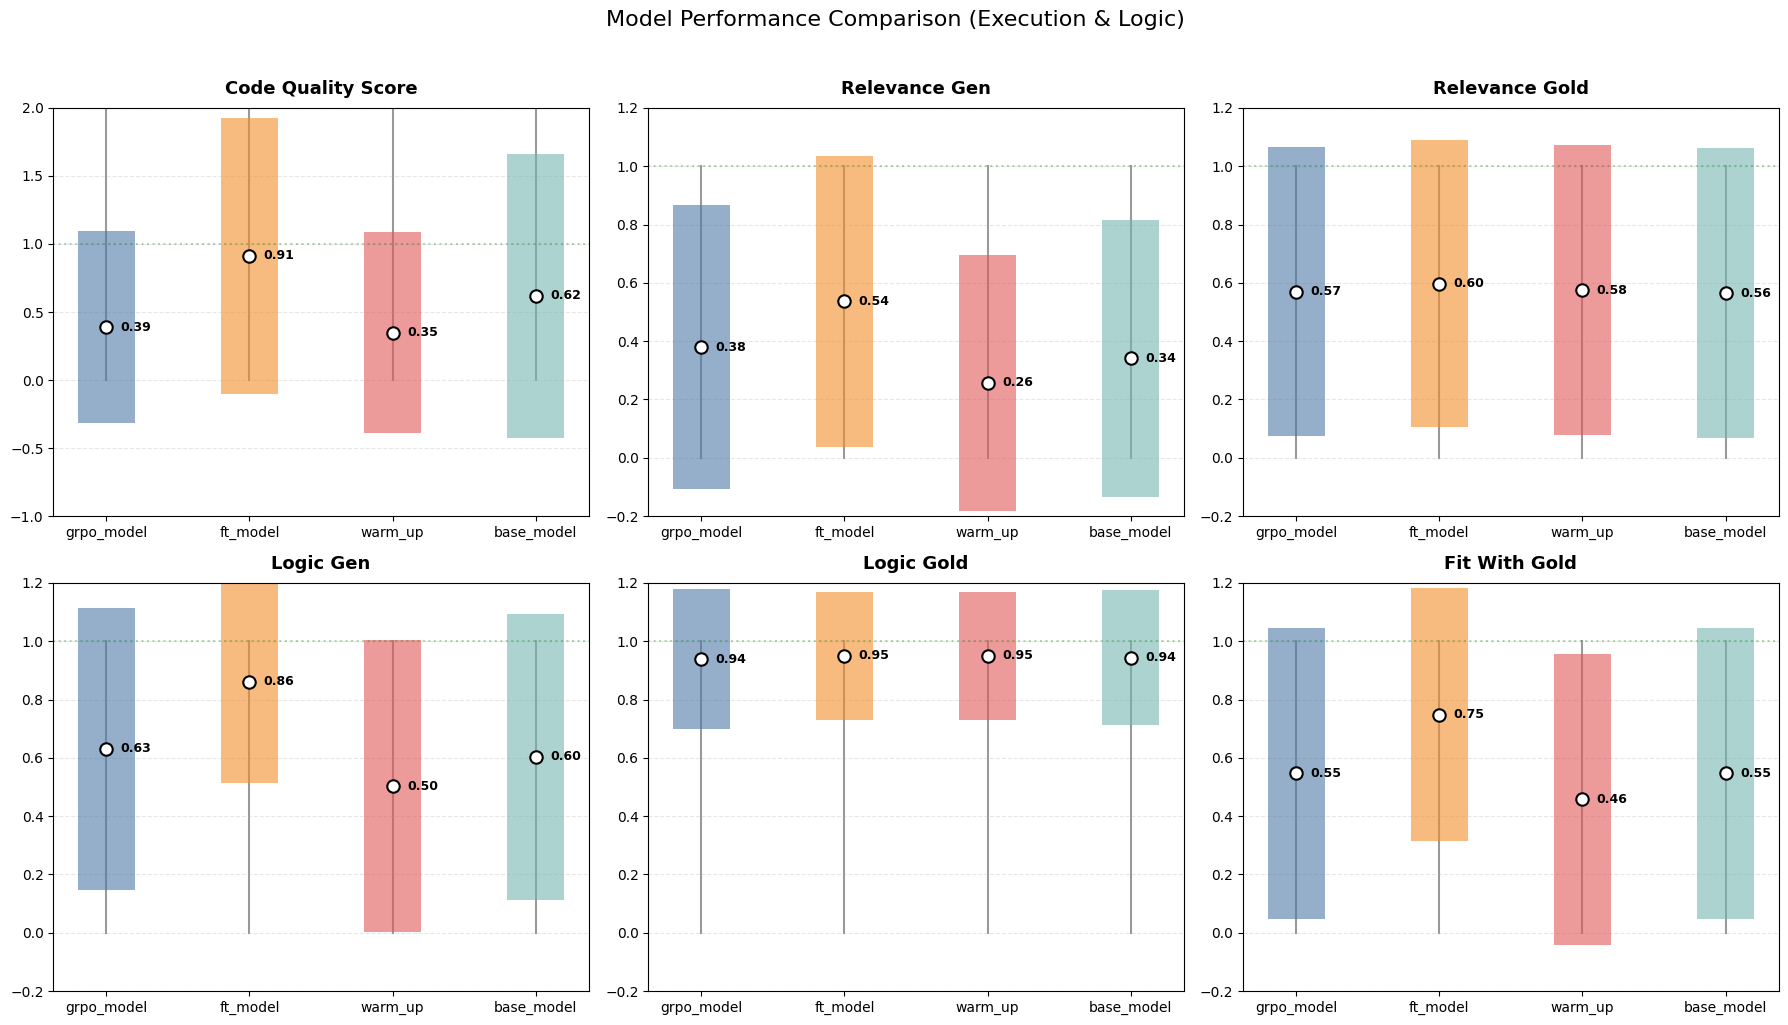

In [ ]:
import matplotlib.pyplot as plt

def plot_score_distributions(list_results_df, model_names):
    """
    Plots the Mean (dot), Std (rectangle), and Min/Max (line) for all evaluation metrics.
    
    Args:
        list_results_df: List of evaluated dataframes containing new execution metrics.
        model_names: List of strings for the legend/x-axis.
    """
    metrics = [
        'code_quality_score', 
        'relevance_gen', 
        'relevance_gold', 
        'logic_gen', 
        'logic_gold', 
        'fit_with_gold'
    ]
    
    num_metrics = len(metrics)
    rows = 2
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(18, 10))
    axes = axes.flatten() 
    
    colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
    bar_width = 0.4
    
    for ax_idx, metric in enumerate(metrics):
        ax = axes[ax_idx]
        pretty_metric = metric.replace('_', ' ').title()
        
        for i, df in enumerate(list_results_df):
            if metric not in df.columns:
                continue
                
            series = df[metric].dropna()
            mean_val = series.mean()
            std_val = series.std() if len(series) > 1 else 0
            min_val = series.min()
            max_val = series.max()
            
            x = i
            color = colors[i % len(colors)]
            
            ax.plot([x, x], [min_val, max_val], color='black', linewidth=1.5, alpha=0.4, zorder=1)
            
            rect_bottom = mean_val - std_val
            rect_height = 2 * std_val
            ax.bar(x, rect_height, bottom=rect_bottom, width=bar_width, 
                   color=color, alpha=0.6, label=model_names[i] if ax_idx==0 else "", zorder=2)
            
            ax.scatter(x, mean_val, color='white', edgecolor='black', s=80, linewidth=1.5, zorder=3)
            
            ax.text(x + 0.1, mean_val, f"{mean_val:.2f}", fontsize=9, va='center', fontweight='bold')

        ax.set_title(f"{pretty_metric}", fontsize=13, fontweight='bold', pad=10)
        ax.set_xticks(range(len(model_names)))
        ax.set_xticklabels(model_names, fontsize=10)
        
        if metric == 'code_quality_score':
            ax.set_ylim(-1, 2) 
        else:
            ax.set_ylim(-0.2, 1.2) 
            
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.axhline(1.0, color='green', linestyle=':', alpha=0.3)

    for j in range(num_metrics, len(axes)):
        axes[j].axis('off')

    plt.suptitle("Model Performance Comparison (Execution & Logic)", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Execution remains the same
plot_score_distributions(list_results_df, ['grpo_model','ft_model','warm_up','base_model'])

# Saving results
list_results_df[0].to_csv('/kaggle/working/grpo_model.csv')
list_results_df[1].to_csv('/kaggle/working/ft_model.csv')